# Images EDA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from tqdm import tqdm

In [ ]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
# Load paths from .env file
data_dir = os.getenv("DATA_DIR")
images_dir = os.getenv("IMAGES_DIR")

# Load the unified TSV file
annotations_file = os.path.join(data_dir, "annotations.tsv")

In [ ]:
df = pd.read_csv(annotations_file, sep="\t")

(1200, 800)
Image Label Task 1: informative
Image Label Confidence: 1.0

Image Label Task 2: infrastructure_and_utility_damage
Image Label Confidence: 1.0

Image Label Task 3: severe_damage
Image Label Confidence: 0.6549


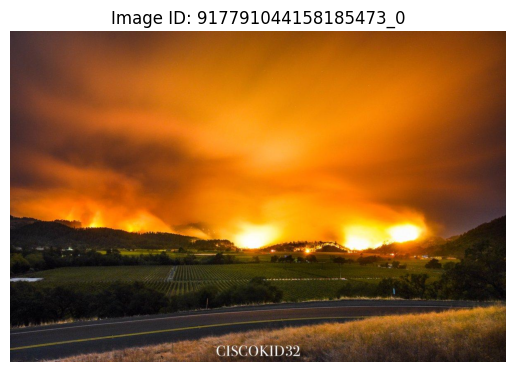

In [ ]:
random_row = df.iloc[100]
image_path = random_row["image_path"]

# Open and display the image
image = Image.open(image_path)

print(f'Image Label Task 1: {random_row["image_info"]}')
print(f'Image Label Confidence: {random_row["image_info_conf"]}')
print(f'\nImage Label Task 2: {random_row["image_human"]}')
print(f'Image Label Confidence: {random_row["image_human_conf"]}')
print(f'\nImage Label Task 3: {random_row["image_damage"]}')
print(f'Image Label Confidence: {random_row["image_damage_conf"]}')

plt.imshow(image)
plt.axis('off')
plt.title(f"Image ID: {df.iloc[0]['image_id']}")
plt.show()


In [ ]:
# Inizializza le liste
widths = []
heights = []
aspect_ratios = []
missing = []

# iteration on each image
for idx, row in tqdm(df.iterrows(), total=len(df)):
    image_path = row["image_path"]

    try:
        with Image.open(image_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h)
    except Exception as e:
        #for missing images
        missing.append(row["image_path"])
        widths.append(None)
        heights.append(None)
        aspect_ratios.append(None)

#Added to the dataframe
df["img_width"] = widths
df["img_height"] = heights
df["img_aspect_ratio"] = aspect_ratios


100%|██████████| 18082/18082 [06:01<00:00, 50.07it/s]


In [ ]:
print(f'{len(df["img_width"].unique())} Different width values')
print(f'{len(df["img_height"].unique())} Different height values')
print(f'{len(df["img_aspect_ratio"].unique())} Different aspect ratio values')


949 Different width values
1037 Different height values
4728 Different aspect ratio values
